<a href="https://colab.research.google.com/github/vivek-kothekar/Disease-Outbreak-Prediction-ML-TAE/blob/main/models/Random_Forest_TAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vivek Kothekar

Roll No: CS23110

Subject: Machine Learning

Topic: Disease Outbreak Prediction (Diabetes Prediction)

Dataset: diabetes.csv

Model Used: Random Forest Classifier

---

### AIM

To implement the Random Forest algorithm on the diabetes dataset for predicting disease occurrence and classifying patients as diabetic or non-diabetic.

---

### DATASET DESCRIPTION

The diabetes dataset is a healthcare dataset containing medical and diagnostic information of patients.

It includes multiple features such as:

* Glucose level
* Blood pressure
* BMI (Body Mass Index)
* Insulin level
* Age

These features are used to analyze the health condition of patients and predict the likelihood of diabetes.

The target variable is **'Outcome'**:

* 0 → Non-diabetic
* 1 → Diabetic

---


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/ML/diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Target Distribution
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


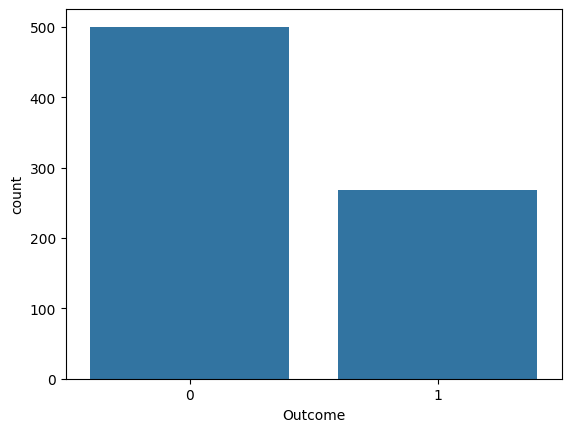

In [8]:
sns.countplot(x='Outcome', data=df)
plt.show()

In [9]:
# Feature and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [10]:
# Train-Test Split (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (537, 8)
Testing shape: (231, 8)


In [11]:
# Model Implementation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [12]:
# Train Model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
# Prediction
y_pred = rf_model.predict(X_test)

In [14]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

Random Forest Accuracy: 75.32%


In [15]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6385542168674698


In [16]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.6625


In [17]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6503067484662577


In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[121  30]
 [ 27  53]]


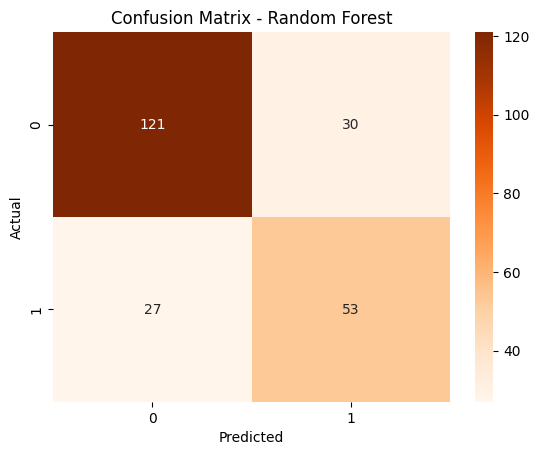

In [19]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       151
           1       0.64      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231



80%,20%

In [21]:
# Random Forest (80-20 split)

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# Train model
rf_model_80 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_80.fit(X_train_80, y_train_80)

RandomForestClassifier(random_state=42)

In [23]:
# Prediction
y_pred_80 = rf_model_80.predict(X_test_80)

In [24]:
# Accuracy
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
print("Random Forest Accuracy (80-20): {:.2f}%".format(accuracy_80 * 100))

Random Forest Accuracy (80-20): 72.08%


In [25]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6385542168674698


In [26]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.6625


In [27]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6503067484662577


In [28]:
# Confusion Matrix
cm_80 = confusion_matrix(y_test_80, y_pred_80)
print(cm_80)

[[77 22]
 [21 34]]


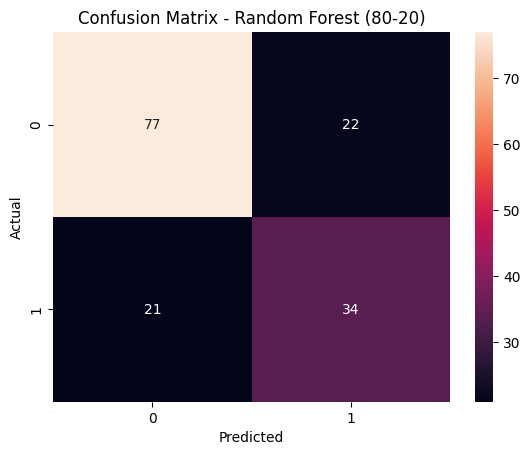

In [29]:
sns.heatmap(cm_80, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
# Classification Report
print(classification_report(y_test_80, y_pred_80))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154

